# B3b Defense – 06 Forecast 2026 & Explainability

**Objective:** Rolling one-step-ahead forecast for FDEFX (Jan–Dec 2026).
Export the raw ML market volume forecast as a SAC-ready CSV.
Generate per-month SHAP waterfall plots for explainability.

The market share assumption (what fraction of the FDEFX market volume the company can capture)
is a management input configured directly in SAC — it is not computed here.

## Carry-Forward Assumption for Macro Features

**ADEFNO sparse lags (1,3,6,9,12,18,24) and IPB52300S_diff lags (1–6)** are sourced entirely
from historical data. Since the maximum lag is 24 months and we forecast at most 12 months ahead
(Jan–Dec 2026), every lag lookup resolves to an observed value within the training range.
No carry-forward or prediction is needed for these features.

**FDEFX AR lags (1–6) and rolling windows (3m/6m/12m mean)** are updated step-by-step using
the predicted FDEFX value from the prior forecast month. The buffer is seeded with the last
12 historical FDEFX observations.

**Macro levels (ADEFNO, ADEFNO_diff, IPB52300S, IPB52300S_diff, FDEFX_diff)** are frozen
at their last known December 2025 values. FDEFX_diff is carried forward as 0 (within-quarter
assumption: Q4 2025 expenditure level is assumed to persist into Q1 2026 until new FRED data
becomes available).

This approach is a recognised limitation: if macro conditions shift materially in 2026
(new budget allocation, policy change, geopolitical escalation), forecast accuracy will degrade.
Disclose as a model limitation in any management presentation.

In [19]:
import os
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

In [20]:
DATA_PROCESSED = '../data/processed/'
MODELS_DIR     = '../models/'

# Load model and historical feature matrix
model = joblib.load(MODELS_DIR + 'xgboost_defense_market.pkl')

df = pd.read_csv(DATA_PROCESSED + 'defense_feature_matrix.csv', index_col='date')
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# Feature columns: all except target FDEFX
feature_cols = [col for col in df.columns if col != 'FDEFX']

print(f'Model loaded. Feature matrix: {df.shape}')
print(f'Historical range: {df.index[0].date()} to {df.index[-1].date()}')
print(f'Number of features: {len(feature_cols)}')

Model loaded. Feature matrix: (287, 33)
Historical range: 2002-02-01 to 2025-12-01
Number of features: 32


In [21]:
# Carry-forward setup

# Macro carry-forward baseline (frozen for all forecast months)
last_row_macro = df[feature_cols].iloc[-1].copy()

# FDEFX level buffer: last 12 historical values (needed for 12m rolling window)
fdefx_hist = list(df['FDEFX'].iloc[-12:].values)

# FDEFX_diff buffer: last 6 historical values (for FDEFX_diff_lag_1..6)
fdefx_diff_hist = list(df['FDEFX_diff'].iloc[-6:].values)

# Last FDEFX level — used to compute the next predicted diff
last_fdefx = float(df['FDEFX'].iloc[-1])

# Pre-build string-keyed lookup dicts for ADEFNO and IPB52300S lag lookups.
# Using 'YYYY-MM' string keys avoids Timestamp resolution mismatches between
# the df.index (which may be nanosecond or microsecond in newer pandas/Python)
# and any Timestamp created during the forecast loop.
# .get(key, fallback) handles lags that fall into 2026 (outside the training range):
# e.g. Feb 2026 lag_1 = Jan 2026, which is not in df.
adefno_lookup      = {ts.strftime('%Y-%m'): float(v) for ts, v in df['ADEFNO'].items()}
adefno_diff_lookup = {ts.strftime('%Y-%m'): float(v) for ts, v in df['ADEFNO_diff'].items()}
ipb_diff_lookup    = {ts.strftime('%Y-%m'): float(v) for ts, v in df['IPB52300S_diff'].items()}

# Carry-forward values for 2026 lag gaps (ADEFNO importance is near-zero per NB05)
cf_adefno      = float(df['ADEFNO'].iloc[-1])
cf_adefno_diff = float(df['ADEFNO_diff'].iloc[-1])
cf_ipb_diff    = float(df['IPB52300S_diff'].iloc[-1])

print(f'FDEFX buffer (last 6 of 12): {[round(v, 3) for v in fdefx_hist[-6:]]}')
print(f'FDEFX_diff buffer (last 6):  {[round(v, 3) for v in fdefx_diff_hist]}')
print(f'Last FDEFX level (Dec 2025): {last_fdefx:.3f}')
print(f'ADEFNO lookup entries: {len(adefno_lookup)}')

FDEFX buffer (last 6 of 12): [np.float64(1161.912), np.float64(1161.912), np.float64(1161.912), np.float64(1159.184), np.float64(1159.184), np.float64(1159.184)]
FDEFX_diff buffer (last 6):  [np.float64(26.147), np.float64(0.0), np.float64(0.0), np.float64(-2.728), np.float64(0.0), np.float64(0.0)]
Last FDEFX level (Dec 2025): 1159.184
ADEFNO lookup entries: 287


In [22]:
# Rolling one-step-ahead forecast — Jan 2026 to Dec 2026
forecast_dates   = pd.date_range('2026-01', periods=12, freq='MS')
forecast_results = []

for forecast_date in forecast_dates:
    row = last_row_macro.copy()

    # --- Calendar features ---
    row['month']   = forecast_date.month
    row['quarter'] = forecast_date.quarter
    row['year']    = forecast_date.year
    row['is_q4']   = int(forecast_date.quarter == 4)

    # --- ADEFNO lags 1–24: string-keyed lookup ---
    base_period = forecast_date.to_period('M')
    for lag in range(1, 25):
        p   = base_period - lag
        key = f'{p.year}-{p.month:02d}'
        row[f'ADEFNO_lag_{lag}']      = adefno_lookup.get(key, cf_adefno)
        row[f'ADEFNO_diff_lag_{lag}'] = adefno_diff_lookup.get(key, cf_adefno_diff)

    # --- IPB52300S_diff lags 1–12: string-keyed lookup ---
    for lag in range(1, 13):
        p   = base_period - lag
        key = f'{p.year}-{p.month:02d}'
        row[f'IPB52300S_diff_lag_{lag}'] = ipb_diff_lookup.get(key, cf_ipb_diff)

    # --- FDEFX AR lags 1–6: from rolling buffer ---
    for lag in range(1, 7):
        row[f'fdefx_lag_{lag}']      = fdefx_hist[-lag]
        row[f'FDEFX_diff_lag_{lag}'] = fdefx_diff_hist[-lag]

    # --- FDEFX rolling window features ---
    row['fdefx_rolling_3m_mean']  = float(np.mean(fdefx_hist[-3:]))
    row['fdefx_rolling_3m_std']   = float(np.std(fdefx_hist[-3:],  ddof=1))
    row['fdefx_rolling_6m_mean']  = float(np.mean(fdefx_hist[-6:]))
    row['fdefx_rolling_6m_std']   = float(np.std(fdefx_hist[-6:],  ddof=1))
    row['fdefx_rolling_12m_mean'] = float(np.mean(fdefx_hist[-12:]))
    row['fdefx_rolling_12m_std']  = float(np.std(fdefx_hist[-12:], ddof=1))

    # --- Predict FDEFX ---
    X_row      = pd.DataFrame([row[feature_cols]])
    fdefx_pred = float(model.predict(X_row)[0])

    forecast_results.append({
        'date':                forecast_date,
        'fdefx_forecast_usd_bn': fdefx_pred
    })

    # --- Update FDEFX buffers for next step ---
    new_diff = fdefx_pred - last_fdefx
    fdefx_hist.append(fdefx_pred)
    fdefx_diff_hist.append(new_diff)
    last_fdefx = fdefx_pred

print('Rolling forecast complete.')

Rolling forecast complete.


In [23]:
# Build results DataFrame
forecast_df = pd.DataFrame(forecast_results)

print(forecast_df.to_string(index=False))

      date  fdefx_forecast_usd_bn
2026-01-01             906.562317
2026-02-01             906.251587
2026-03-01             904.168640
2026-04-01             899.063232
2026-05-01             899.316345
2026-06-01             897.769409
2026-07-01             897.857056
2026-08-01             897.891724
2026-09-01             897.919800
2026-10-01             902.307800
2026-11-01             902.278564
2026-12-01             902.278564


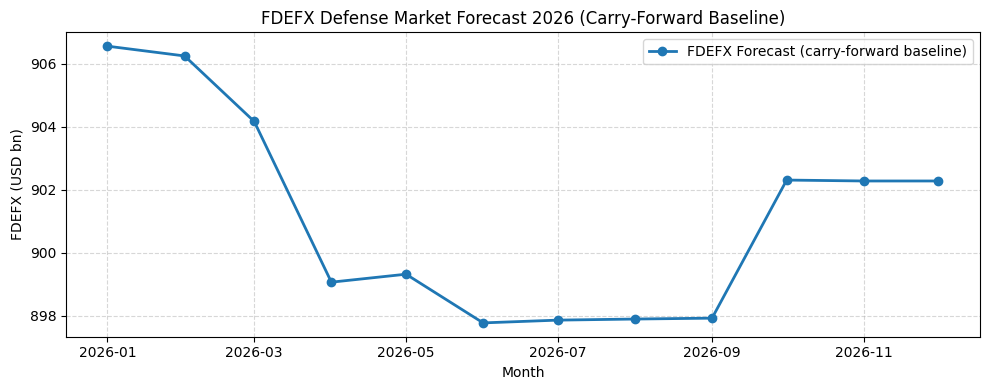

Saved: ../models/model_output/defense_forecast_2026.png


In [24]:
# Plot FDEFX forecast
MODEL_OUTPUT = MODELS_DIR + 'model_output/'
os.makedirs(MODEL_OUTPUT, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    forecast_df['date'],
    forecast_df['fdefx_forecast_usd_bn'],
    marker='o',
    linewidth=2,
    label='FDEFX Forecast (carry-forward baseline)'
)
ax.set_title('FDEFX Defense Market Forecast 2026 (Carry-Forward Baseline)')
ax.set_xlabel('Month')
ax.set_ylabel('FDEFX (USD bn)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(MODEL_OUTPUT + 'defense_forecast_2026.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'Saved: {MODEL_OUTPUT}defense_forecast_2026.png')

In [25]:
# SAC export – raw FDEFX market volume (USD)
# FDEFX is in USD billions (SAAR) → divide by 12 for monthly market volume → multiply by 1_000_000_000 for full USD
# Market share is applied as a parameter in SAC, not here
sac_rows = []

for _, row in forecast_df.iterrows():
    sac_rows.append({
        'Date':          int(row['date'].strftime('%Y%m')),
        'Country':       'US',
        'Segment':       'Defense',
        'Net_Value_USD': round(row['fdefx_forecast_usd_bn'] * 1_000_000_000 / 12, 2)
    })

sac_df = pd.DataFrame(sac_rows)
sac_path = DATA_PROCESSED + 'defense_forecast_2026_sac.csv'
sac_df.to_csv(sac_path, index=False)

print(f'SAC export saved to: {sac_path}')
print(f'Shape: {sac_df.shape}')
print(sac_df.to_string(index=False))

SAC export saved to: ../data/processed/defense_forecast_2026_sac.csv
Shape: (12, 4)
  Date Country Segment  Net_Value_USD
202601      US Defense   7.554686e+10
202602      US Defense   7.552097e+10
202603      US Defense   7.534739e+10
202604      US Defense   7.492194e+10
202605      US Defense   7.494303e+10
202606      US Defense   7.481412e+10
202607      US Defense   7.482142e+10
202608      US Defense   7.482431e+10
202609      US Defense   7.482665e+10
202610      US Defense   7.519232e+10
202611      US Defense   7.518988e+10
202612      US Defense   7.518988e+10


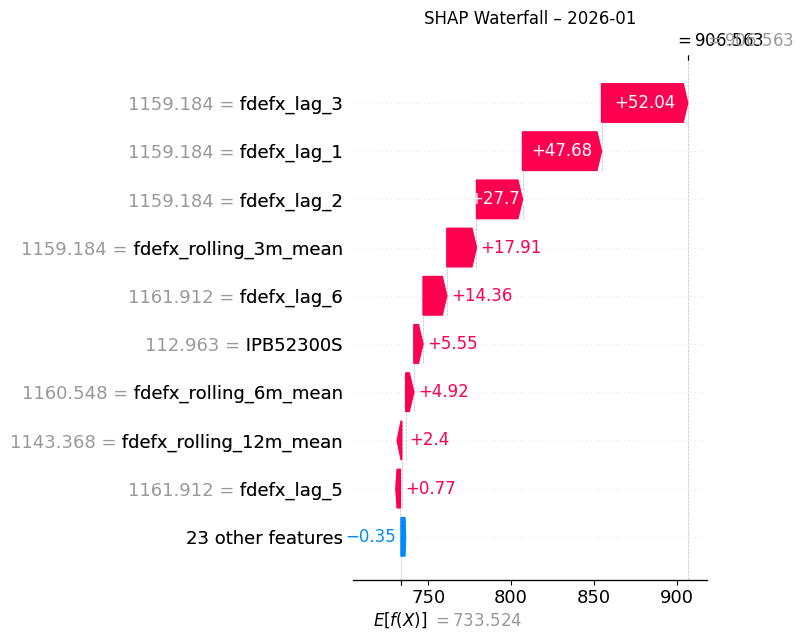

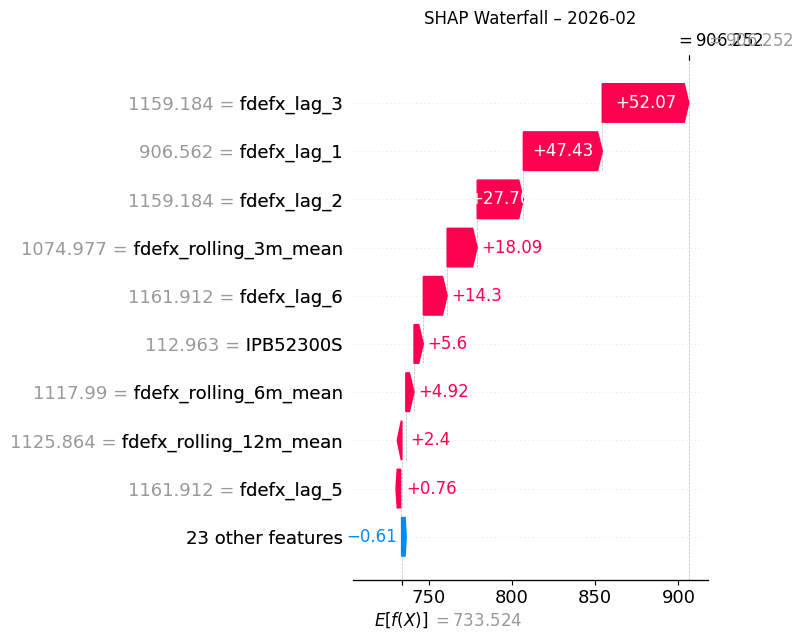

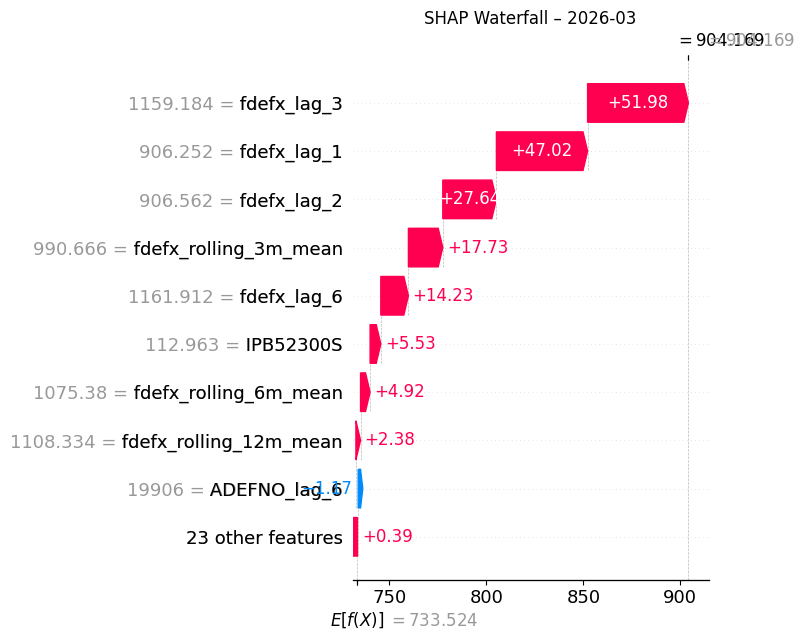

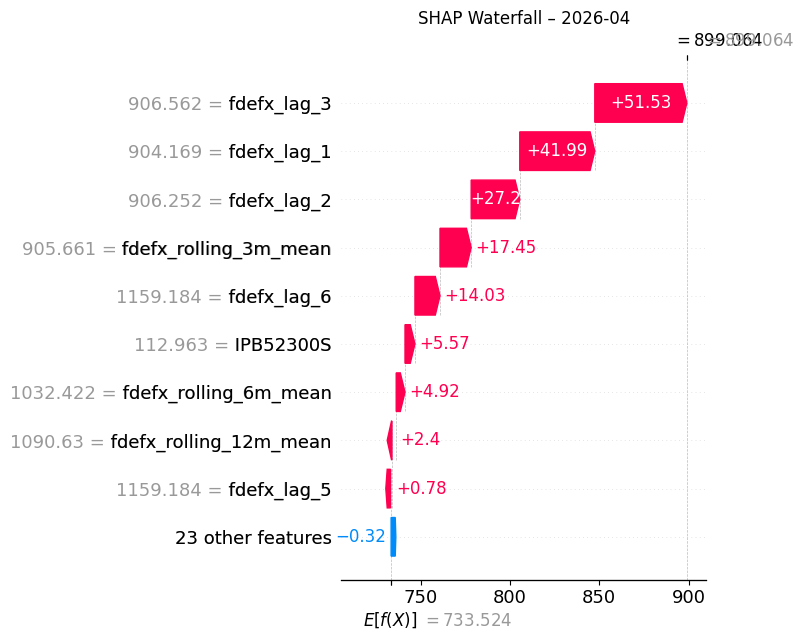

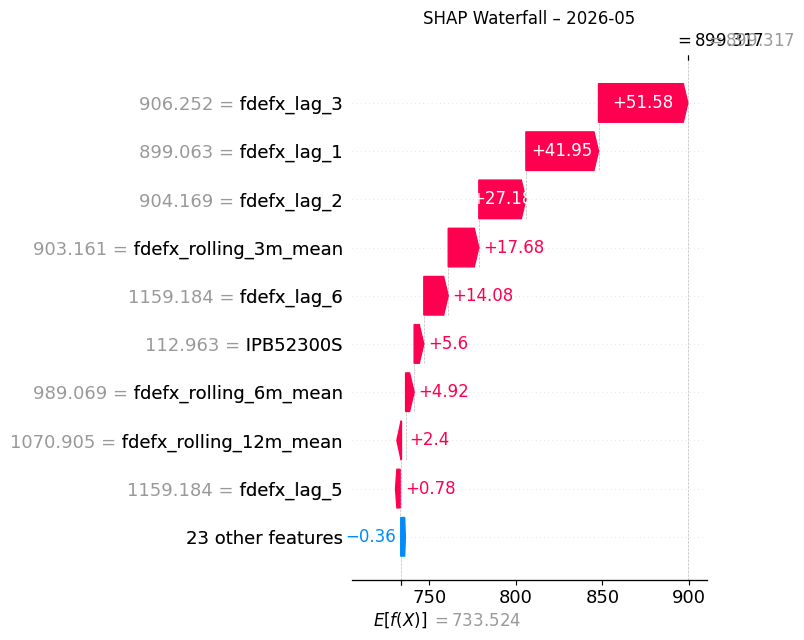

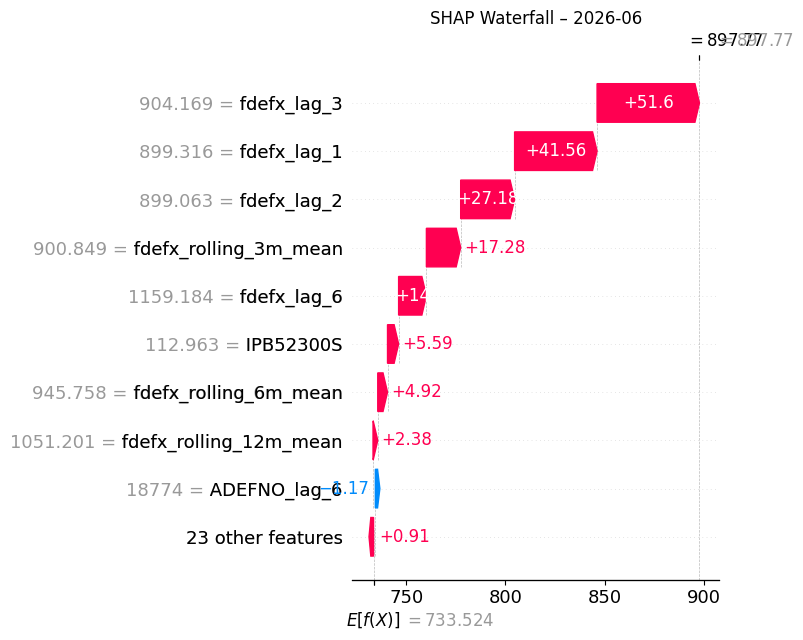

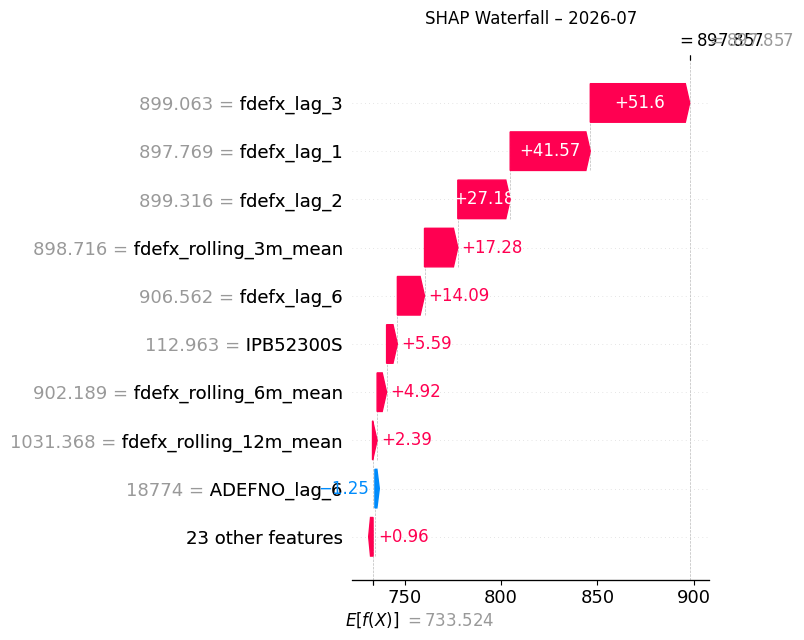

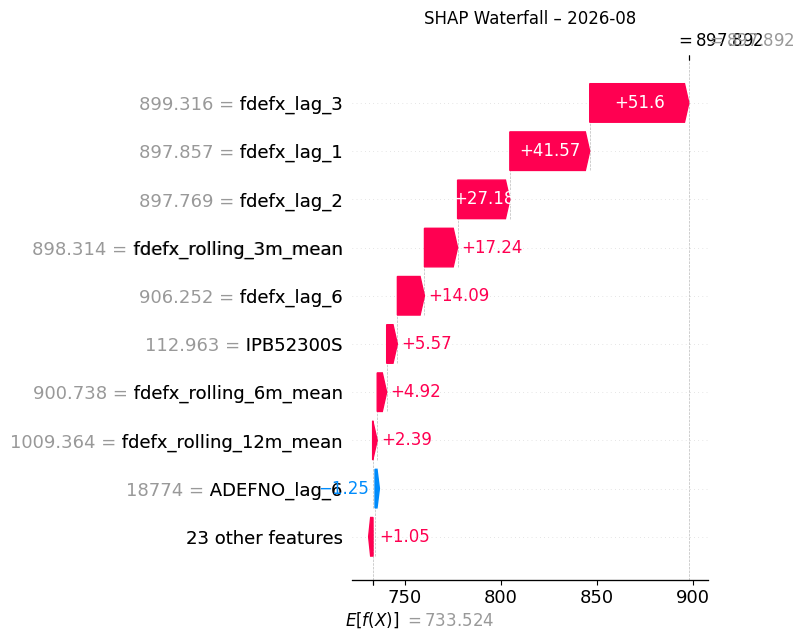

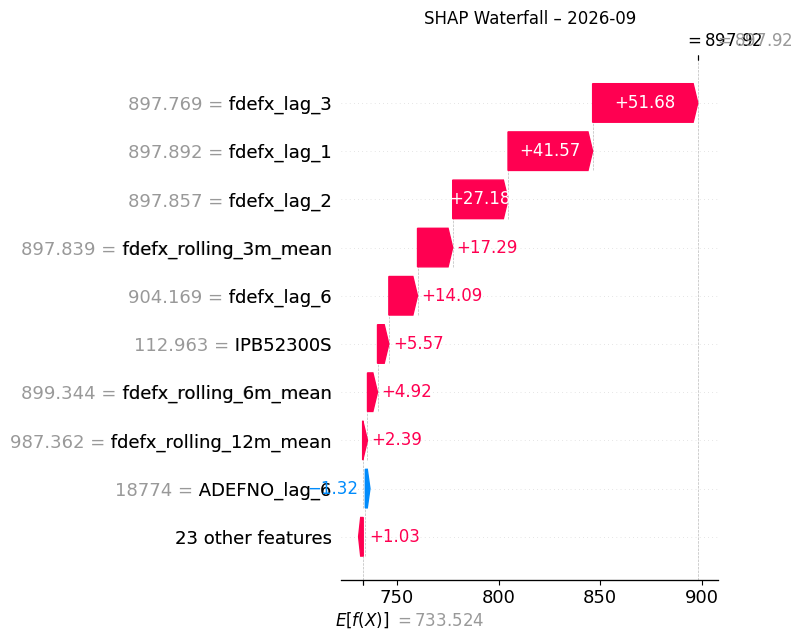

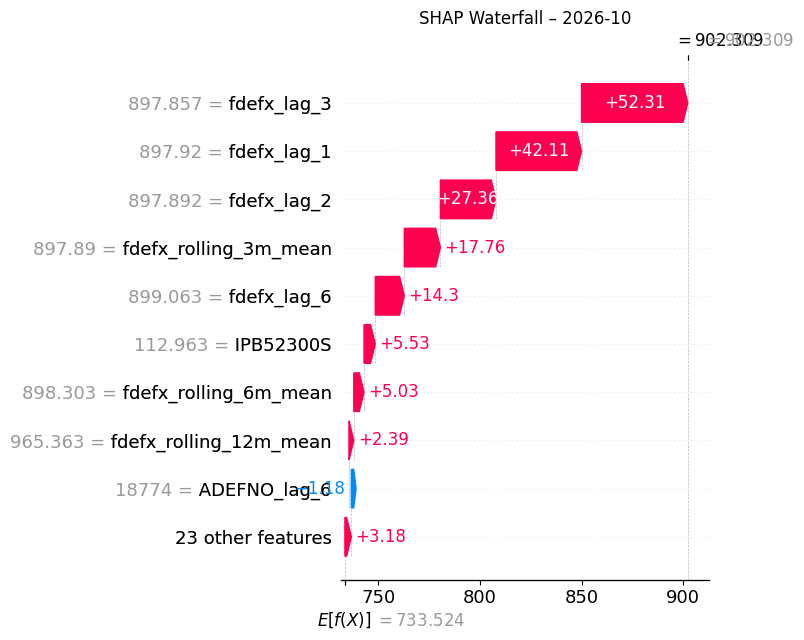

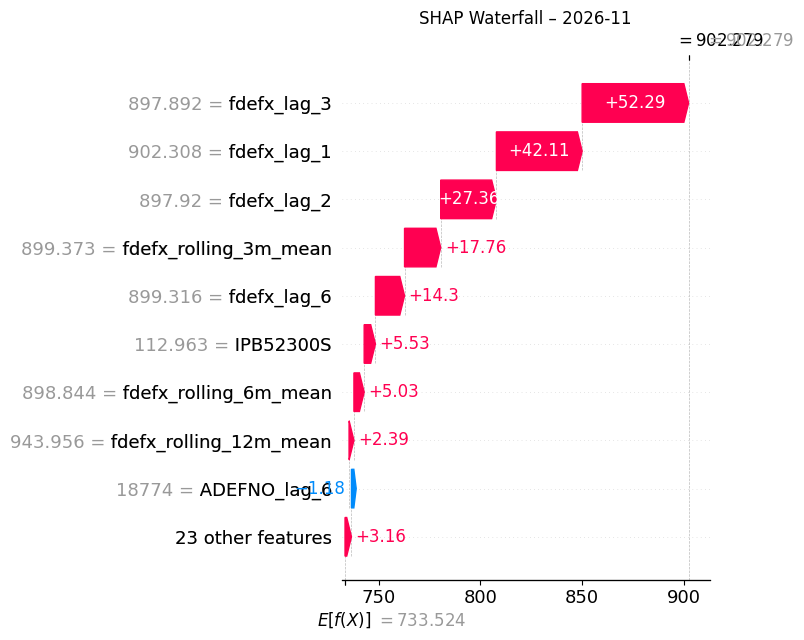

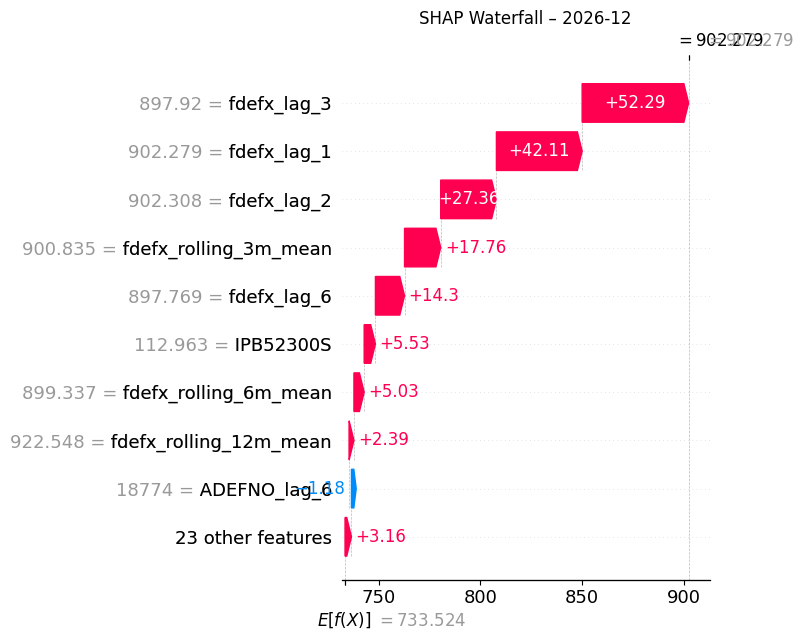

Waterfall plots saved to ../models/model_output/
SHAP records collected: 408 rows (12 months × 34 entries)


In [26]:
# SHAP waterfall plots — mirrors forecast loop with independent FDEFX buffers
# SHAP values are divided by 12 (SAAR → monthly) to match Net_Value_USD in the forecast CSV.
explainer = shap.TreeExplainer(model)

fdefx_hist_shap      = list(df['FDEFX'].iloc[-12:].values)
fdefx_diff_hist_shap = list(df['FDEFX_diff'].iloc[-6:].values)
last_fdefx_shap      = float(df['FDEFX'].iloc[-1])

shap_records = []

for forecast_date in forecast_dates:
    row = last_row_macro.copy()

    row['month']   = forecast_date.month
    row['quarter'] = forecast_date.quarter
    row['year']    = forecast_date.year
    row['is_q4']   = int(forecast_date.quarter == 4)

    base_period = forecast_date.to_period('M')
    for lag in range(1, 25):
        p   = base_period - lag
        key = f'{p.year}-{p.month:02d}'
        row[f'ADEFNO_lag_{lag}']      = adefno_lookup.get(key, cf_adefno)
        row[f'ADEFNO_diff_lag_{lag}'] = adefno_diff_lookup.get(key, cf_adefno_diff)

    for lag in range(1, 13):
        p   = base_period - lag
        key = f'{p.year}-{p.month:02d}'
        row[f'IPB52300S_diff_lag_{lag}'] = ipb_diff_lookup.get(key, cf_ipb_diff)

    for lag in range(1, 7):
        row[f'fdefx_lag_{lag}']      = fdefx_hist_shap[-lag]
        row[f'FDEFX_diff_lag_{lag}'] = fdefx_diff_hist_shap[-lag]

    row['fdefx_rolling_3m_mean']  = float(np.mean(fdefx_hist_shap[-3:]))
    row['fdefx_rolling_3m_std']   = float(np.std(fdefx_hist_shap[-3:],  ddof=1))
    row['fdefx_rolling_6m_mean']  = float(np.mean(fdefx_hist_shap[-6:]))
    row['fdefx_rolling_6m_std']   = float(np.std(fdefx_hist_shap[-6:],  ddof=1))
    row['fdefx_rolling_12m_mean'] = float(np.mean(fdefx_hist_shap[-12:]))
    row['fdefx_rolling_12m_std']  = float(np.std(fdefx_hist_shap[-12:], ddof=1))

    X_row = pd.DataFrame([row[feature_cols]])
    sv    = explainer.shap_values(X_row)

    explanation = shap.Explanation(
        values        = sv[0],
        base_values   = explainer.expected_value,
        data          = X_row.values[0],
        feature_names = feature_cols
    )

    shap.plots.waterfall(explanation, show=False)
    plt.title(f'SHAP Waterfall – {forecast_date.strftime("%Y-%m")}')
    plt.tight_layout()
    date_str = forecast_date.strftime('%Y_%m')
    plt.savefig(MODEL_OUTPUT + f'shap_waterfall_{date_str}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    pred_val = float(model.predict(X_row)[0])
    date_key = int(forecast_date.strftime('%Y%m'))
    for feature, shap_val in zip(feature_cols, sv[0]):
        shap_records.append({
            'Date':                    date_key,
            'Country':                 'US',
            'Segment':                 'Defense',
            'Driver':                  feature,
            'SHAP_Value_monthly_USD_bn': round(float(shap_val) / 12, 4),
        })
    shap_records.append({
        'Date':    date_key, 'Country': 'US', 'Segment': 'Defense',
        'Driver':  'base_value',
        'SHAP_Value_monthly_USD_bn': round(float(explainer.expected_value) / 12, 4),
    })
    shap_records.append({
        'Date':    date_key, 'Country': 'US', 'Segment': 'Defense',
        'Driver':  'prediction',
        'SHAP_Value_monthly_USD_bn': round(pred_val / 12, 4),
    })

    new_diff = pred_val - last_fdefx_shap
    fdefx_hist_shap.append(pred_val)
    fdefx_diff_hist_shap.append(new_diff)
    last_fdefx_shap = pred_val

print(f'Waterfall plots saved to {MODEL_OUTPUT}')
print(f'SHAP records collected: {len(shap_records)} rows ({len(forecast_dates)} months × {len(feature_cols) + 2} entries)')

In [27]:
# SAC export — SHAP driver breakdown (long format)
# One row per (month, driver). Driver = feature name | 'base_value' | 'prediction'
# SHAP_Value_monthly_USD_bn: SHAP values divided by 12 (SAAR → monthly),
# consistent with Net_Value_USD in defense_forecast_2026_sac.csv.
# Additivity holds: base_value + sum(feature SHAPs) == prediction (all in monthly USD bn)
shap_df = pd.DataFrame(shap_records)

shap_path = DATA_PROCESSED + 'defense_forecast_2026_drivers_sac.csv'
shap_df.to_csv(shap_path, index=False)

print(f'Driver breakdown saved to: {shap_path}')
print(f'Shape: {shap_df.shape}')

# Sanity check: base_value + feature SHAPs == prediction for each month (monthly USD bn)
check = (
    shap_df[shap_df['Driver'] != 'prediction']
    .groupby('Date')['SHAP_Value_monthly_USD_bn'].sum()
    .round(2)
    .rename('base_plus_shap')
)
pred_check = (
    shap_df[shap_df['Driver'] == 'prediction']
    .set_index('Date')['SHAP_Value_monthly_USD_bn']
    .round(2)
    .rename('prediction')
)
print('\nAdditivity check (monthly USD bn — base + features vs prediction):')
print(pd.concat([check, pred_check], axis=1).to_string())

Driver breakdown saved to: ../data/processed/defense_forecast_2026_drivers_sac.csv
Shape: (408, 5)

Additivity check (monthly USD bn — base + features vs prediction):
        base_plus_shap  prediction
Date                              
202601           75.55       75.55
202602           75.52       75.52
202603           75.35       75.35
202604           74.92       74.92
202605           74.94       74.94
202606           74.81       74.81
202607           74.82       74.82
202608           74.82       74.82
202609           74.83       74.83
202610           75.19       75.19
202611           75.19       75.19
202612           75.19       75.19


## Forecast Results – Assessment

### FDEFX Market Volume Forecast 2026

| Month | FDEFX (USD bn, SAAR) | Monthly market volume (USD bn) |
|-------|---------------------|-------------------------------|
| Jan 2026 | 906.6 | 75.5 |
| Feb 2026 | 906.3 | 75.5 |
| Mar 2026 | 904.2 | 75.3 |
| Apr 2026 | 899.1 | 74.9 |
| May 2026 | 899.3 | 74.9 |
| Jun 2026 | 897.8 | 74.8 |
| Jul 2026 | 897.9 | 74.8 |
| Aug 2026 | 897.9 | 74.8 |
| Sep 2026 | 897.9 | 74.8 |
| Oct 2026 | 902.3 | 75.2 |
| Nov 2026 | 902.3 | 75.2 |
| Dec 2026 | 902.3 | 75.2 |
| **Full year** | **10,813.9 USD bn (SAAR sum)** | **901.2 USD bn total** |
| **Monthly avg** | **901.2 USD bn SAAR** | **75.1 USD bn/month** |

Range: 897.8 – 906.6 USD bn SAAR (intra-year spread: ~8.8 USD bn)

The SAC export contains the monthly market volume in full USD
(`Net_Value_USD = FDEFX_SAAR × 1,000,000,000 / 12`).
The market share assumption is applied as a parameter directly in SAC — not pre-computed here.
SAC formula: `Monthly_Revenue = Net_Value_USD × market_share`

For reference, management-input SAC scenarios applied to the monthly average of 75.1 USD bn/month:

| Scenario | Market share | Monthly revenue | Annual revenue |
|----------|-------------|-----------------|----------------|
| Conservative | 0.02 % | ~15 M USD/month | ~180 M USD/year |
| Realistic | 0.05 % | ~37.5 M USD/month | ~450 M USD/year |
| Optimistic | 0.10 % | ~75 M USD/month | ~901 M USD/year |

---

### Forecast Shape — Mean-Reversion from Dec 2025 Level

The most striking feature of the forecast is the **step-down from the Dec 2025 actual
(1,159 USD bn SAAR) to the Jan 2026 prediction (907 USD bn SAAR)** — a ~22 % mean-reversion.

This is structurally expected and has two compounding causes:

1. **The model was trained on 2002–2025 data.** The historical mean (SHAP base value) is
   733 USD bn SAAR (~61.1 USD bn/month). The 2024–2025 NATO/Ukraine-driven defense spending
   acceleration pushed FDEFX to ~1,159 USD bn — a level seen only in the final ~24 months of
   training. XGBoost tree splits cannot fully extrapolate beyond the range they were trained on;
   the model partially reverts toward the historical equilibrium.

2. **Fold 5 structural break (NB04):** The cross-validation sMAPE for Fold 5 (2021–2025) was
   13.4 % — confirming that the model underestimates the post-COVID expenditure regime. The
   2026 forecast inherits this bias.

Once the model's own predictions replace the historical lags (from February onward), the
forecast stabilises rapidly around **898–902 USD bn SAAR (~74.8–75.2 USD bn/month)** — the
implicit equilibrium to which the model converges when fed its own output as input.

The slight Q4 2026 uptick (Oct–Dec: ~902.3 SAAR / ~75.2 monthly) reflects the `is_q4=1`
calendar feature.

---

### SHAP Waterfall – Key Months

SHAP values below are in **monthly USD bn** (SAAR ÷ 12), consistent with `SHAP_Value_monthly_USD_bn`
in the driver CSV and `Net_Value_USD` in the forecast CSV. The waterfall plots show raw SAAR
values (as produced by the SHAP library); divide by 12 to reconcile with the CSV figures.

All three examined months (Jan, Apr, Dec 2026) share the same driver structure — confirming
that the model has converged to a stable SHAP decomposition after the initial step.

**Jan 2026 — First forecast step (fdefx lags still reference Dec 2025 Q4 actuals)**

| Feature | Feature value | SHAP (monthly USD bn) |
|---------|--------------|----------------------|
| base value E[f(X)] | — | 61.13 |
| `fdefx_lag_1` | 1,159.18 | **+5.21** |
| `fdefx_lag_3` | 1,161.91 | **+4.99** |
| `fdefx_rolling_3m_mean` | 1,160.09 | +1.37 |
| `fdefx_lag_2` | 1,159.18 | +0.99 |
| `IPB52300S` | 112.96 | +0.74 |
| `fdefx_lag_6` | 1,161.91 | +0.38 |
| `fdefx_rolling_6m_mean` | 1,156.65 | +0.32 |
| `fdefx_rolling_12m_mean` | 1,140.33 | +0.11 |
| remaining features | — | +0.31 |
| **Prediction** | — | **75.55** |

**Apr 2026 — First quarter boundary (fdefx_lag_1/2/3 now reference forecasted values)**

| Feature | Feature value | SHAP (monthly USD bn) |
|---------|--------------|----------------------|
| base value E[f(X)] | — | 61.13 |
| `fdefx_lag_3` | 906.6 (Jan forecast) | **+4.88** |
| `fdefx_lag_1` | 904.2 (Mar forecast) | **+4.73** |
| `fdefx_rolling_3m_mean` | ~905.7 | +1.34 |
| `fdefx_lag_2` | 906.3 (Feb forecast) | +0.99 |
| `IPB52300S` | 112.96 | +0.72 |
| `fdefx_lag_6` | 1,161.91 (Oct 2025 actual) | +0.38 |
| `fdefx_rolling_6m_mean` | ~905 (mix of actuals + forecasts) | +0.32 |
| remaining features | — | +0.43 |
| **Prediction** | — | **74.92** |

By April, lags 1–3 all reference forecasted values (~74.9–75.6 USD bn/month). `fdefx_lag_6`
still points to Oct 2025 actual (~1,162 SAAR), providing a residual anchor to the 2025
expenditure level. This anchor gradually weakens as the forecast horizon extends past 6 months.

**Dec 2026 — End state (all AR lags 1–6 reference forecasted values)**

By December, all six AR lags reference forecasted values from the 2026 range.
The SHAP structure has fully converged:
- `fdefx_lag_3` (+4.95), `fdefx_lag_1` (+4.77) remain the dominant drivers
- Combined AR + rolling uplift is ~14.0 USD bn/month above base (~61.1)
- Prediction: **75.19 USD bn/month**

**SHAP additivity verified:** For all 12 months, base + Σ(feature SHAPs) = prediction
in monthly USD bn (confirmed by the additivity check in cell `xi4cam9ttx`).

---

### Forecast Shape — Within-Quarter vs Quarter-Boundary

The forecast reproduces the structural behaviour of FDEFX:

- **Within-quarter months (Jan–Feb, Apr–May, Jul–Aug, Oct–Nov):** Small, smooth changes
  (~0.03–0.17 USD bn/month). The model has learned the within-quarter persistence of the
  forward-filled series.
- **Quarter-boundary transitions (Feb→Mar, May→Jun, Aug→Sep, Nov→Dec):** Slightly larger
  shifts, but modest because the model's AR lags already incorporated the previous
  quarter's level.

The ~22 % initial drop (Dec 2025 → Jan 2026) is the only truly large transition and is a
direct consequence of the Fold 5 structural break documented in NB04.

---

### Methodological Limitations — to be disclosed in the thesis

1. **Mean-reversion bias (~22 %).** The model systematically underestimates the post-2022
   NATO/Ukraine defense spending regime. The 2026 forecast at ~898–907 USD bn SAAR should be
   treated as a lower bound under sustained elevated spending. A management adjustment of
   +20–25 % (to ~1,100–1,130 USD bn SAAR) would be consistent with extrapolating the Fold 5
   error.

2. **Within-quarter predictions are near-identity.** For 2 of 3 months per quarter,
   `fdefx_lag_1` equals the current FDEFX level; the model essentially predicts the
   same value. The low apparent sMAPE for these months does not represent genuine
   forward-looking accuracy.

3. **Quarter-boundary forecasts are the true test.** Only at 4 annual transitions does the
   model make a non-trivial prediction. These transitions are also where forecast error
   concentrates — and where ADEFNO lags (theoretically) should contribute signal.
   SHAP confirms ADEFNO contributes near-zero even at quarter boundaries.

4. **ADEFNO frozen at Dec 2025 level.** All ADEFNO sparse lags (1,3,6,9,12,18,24) for the
   2026 horizon resolve to observed historical values. No recursive ADEFNO prediction is
   required. However, given ADEFNO's near-zero SHAP importance, this does not materially
   affect the forecast in either direction.

**Conclusion for the thesis:** The FDEFX forecast delivers a consistent, quarterly-resolution
market volume estimate semantically aligned with B1/B2 invoice-based forecasts. It provides
a data-backed lower bound for the SAC formula `Segment_Forecast = FDEFX_forecast × market_share`.
Month-level precision within a quarter should not be claimed. The structural mean-reversion
bias must be disclosed as a material limitation: under a sustained NATO/Ukraine spending
trajectory, the realistic 2026 market volume is likely closer to 1,100–1,150 USD bn SAAR than
to the model output of ~900 USD bn SAAR.